# <center>MDSA D214 Data Analytics Graduate Capstone</center> 

## <center>Task 2  Data Analytics Report and Executive Summary</center>

## <center>Justin Jordan</center>

## <center>9/5/2026</center>

## <center>WGU</center>



## A - Research Question

Can we forecast the future stock price using time series analysis based on historical stock data?

This study will utilize an ARIMA model to forecast future Microsoft stock prices by analyzing the historical time series data and identifying patterns or trends within the time series.  By examining the differences between past and future values, ARIMA assists in predicting trends in financial markets, such as stock prices or company earnings, based on historical performances. This model leverages autoregressive properties, making it effective for short-term forecasting where past data significantly influences future outcomes (Hayes, 2026).  

The stock market plays an important role in the economy by allowing businesses to raise money, help people grow wealth and acts as an indicator to the overall health of the economy.  The movement or health of the stock market can impact a company in a variety of ways.  The higher the shares are priced, the  more a company is worth in the market.  The lower the shares are priced, the less a company is worth.  Stock prices fluctuate from day to day making stock price prediction important to a company shareholders as nobody invests to lose money.  The objective is to analyze the historical stock price and identify any patterns or trends to develop a model that can accurately predict the future stock price.  

The hypothesis for the project:
- **Null hypothesis:** The future stock price cannot be predicted with 80% accuracy
- **Alternate Hypothesis:** The future stock price can be predicted with 80% accuracy

The accuracy of the model will be evaluated by Mean Absolute Percentage Error or MAPE.  If the MAPE is greater than 20%, the null hypothesis will be accepted and the alternate will be rejected.  If the MAPE is less than 20%, the null hypothesis will be rejected and the alternate will be accepted.   
      

## B - Data Collection

The data used for this analysis is publicly available on Kaggle’s website and can be found here:  https://www.kaggle.com/datasets/adilshamim8/microsoft-stock-price-history/data.  
The dataset contains 10,094 rows before cleaning.  Historical data is needed for time series and ARIMA to forecast the future stock price.    


The data set includes the following variables of date, close, high, low, open and volume between March 26th 1986 and April 20th 2026. 

Column	Description
Date	Trading Date
Close	Price at market close
High	Highest price during trading day
Low	Lowest price during trading day
Open	Price at market open
Volume	Total shares traded on the given day

An advantage of this dataset is that we do not need to contact the owner of it since the information is publicly available.  One disadvantage of the dataset would be that it is limited by the accuracy and completeness of information made publicly available.  The dataset will be delimited by removing any records that have missing or incomplete values.  Additionally, less data may be used in the building of the model to help performance and because old patterns in the market may skew the results from recent trends (Bora, 2021).     

The main challenge with a publicly available dataset is making sure the data is properly cleaned before analysis can be done.  To overcome this challenge, exploration and cleaning of the data will be done before the analysis can begin.  This will ensure the accuracy of the analysis and models built can be trusted without uncertainty.  

The Microsoft Stock Price History data will be downloaded from Kaggle and is one CSV file containing 6 columns and 10,094 rows.  The data set will then be loaded into a Jupyter Notebook where Python will be used to explore and clean the data.  Next, the data will be evaluated for stationarity, and additional steps may be taken depending on the outcome of the evaluation.  Finally, the data set will be validated using statistics and visualizations to confirm the data is ready to be forecasted.               
        
        

## C - Data Extraction and Preparation

Python will be used in a Jupyter Notebook within Visual Studio Code.  The data set will be loaded into a data frame using Pandas where it will be checked for null values and formatting differences.  As part of the cleaning process, the cleaned data will be put into a new data frame that will be used for the model.  Only the date and close columns will be used in the model.            
 
Python will be used within a Jupyter Notebook.  Jupyter Notebooks are especially useful for “showing the work” that your data team has done through a combination of codes, markdown, links and images (Staff, 2022).  The Python ecosystem is the dominant platform for applied Machine Learning.  The primary rationale for adopting Python for time series forecasting is that it is a general-purpose programming language that you can use both for experimentation and production (Lazzeri, 2021).  One disadvantage to using Jupyter Notebooks in VSCode is that sometimes the base environment being used for the kernel can mess up and not start (Minhas, 2025).  

Pandas is a python library that provides a DataFrame object, a two-dimensional tabular data structure that allows for easy manipulation and analysis of data. It offers intuitive indexing, column operations, and supports various data types. This representation simplifies data analysis tasks and facilitates efficient data exploration (Patil, 2023).  A disadvantage to the pandas library is that it can be challenging for beginners to understand and fully utilize all of the features it has to offer.  

Matplotlib is used to generate visualizations within this project.  It is an easy way to create simple or complex visualizations of the data that are easy to read.  A disadvantage of Matplotlib is that the visualizations created are static. Dashboards and interactive reports have become the norm in many fields, making static charts feel outdated (Loewen, 2025).


In [63]:
# import libraries and df load
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats
from scipy.signal import periodogram
import sklearn
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import matplotlib.gridspec as gridspec
from datetime import datetime
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# code for data frame
og_df = pd.read_csv("C:/users/jjord/Documents/WGU/D214/PA2/Microsoft_stock_data.csv")

# Profile of Data Frame
og_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10094 entries, 0 to 10093
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    10094 non-null  object 
 1   Close   10094 non-null  float64
 2   High    10094 non-null  float64
 3   Low     10094 non-null  float64
 4   Open    10094 non-null  float64
 5   Volume  10094 non-null  int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 473.3+ KB


In [64]:
og_df.head()


,Date,Close,High,Low,Open,Volume
0,1986-03-26,0.057666,0.058195,0.055550,0.056079,22752000
1,1986-03-27,0.058724,0.058724,0.057666,0.057666,16848000
2,1986-03-31,0.058195,0.058724,0.057137,0.058724,12873600
3,1986-04-01,0.057666,0.058195,0.057666,0.058195,11088000
4,1986-04-02,0.058195,0.059253,0.057666,0.057666,27014400


In [65]:
og_df.tail()

,Date,Close,High,Low,Open,Volume
10089,2026-04-14,393.109985,394.690002,386.519989,387.920013,37504500
10090,2026-04-15,411.220001,414.369995,396.730011,398.000000,45063400
10091,2026-04-16,420.260010,420.820007,412.140015,419.859985,41642400
10092,2026-04-17,422.790009,431.579987,420.690002,424.820007,48568200
10093,2026-04-20,418.070007,423.329987,416.299988,421.144989,27240190


In [66]:
og_df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [67]:
#convert date to datetime
og_df['Date'] = pd.to_datetime(og_df['Date'])
og_df.head()

,Date,Close,High,Low,Open,Volume
0,1986-03-26,0.057666,0.058195,0.055550,0.056079,22752000
1,1986-03-27,0.058724,0.058724,0.057666,0.057666,16848000
2,1986-03-31,0.058195,0.058724,0.057137,0.058724,12873600
3,1986-04-01,0.057666,0.058195,0.057666,0.058195,11088000
4,1986-04-02,0.058195,0.059253,0.057666,0.057666,27014400


In [68]:
og_df.tail()

,Date,Close,High,Low,Open,Volume
10089,2026-04-14,393.109985,394.690002,386.519989,387.920013,37504500
10090,2026-04-15,411.220001,414.369995,396.730011,398.000000,45063400
10091,2026-04-16,420.260010,420.820007,412.140015,419.859985,41642400
10092,2026-04-17,422.790009,431.579987,420.690002,424.820007,48568200
10093,2026-04-20,418.070007,423.329987,416.299988,421.144989,27240190


Since the original data begins in 1986, we run the risk of overfitting our historical data which may result in less accurate predictions (Indicio Technologies, 2024).  As part of the data preparation process to help prevent overfitting, only the last 10 years of data will be used for the model.  A new dataframe will be created with containing the last 10 years of data with the variables of Date and Close.  

In [69]:
#create new dataframe with only date and close from past 10 years

col_to_new_df = ['Date', 'Close']
start_date = '2016-01-01'
end_date = '2026-04-20'

df = og_df.loc[og_df['Date'].between(start_date, end_date), col_to_new_df]

df.set_index('Date', inplace=True)

In [70]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2588 entries, 2016-01-04 to 2026-04-20
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2588 non-null   float64
dtypes: float64(1)
memory usage: 40.4 KB


In [71]:
df.head()


,Close
Date,
2016-01-04,47.874187
2016-01-05,48.092598
2016-01-06,47.218975
2016-01-07,45.576580
2016-01-08,45.716370


In [72]:
df.tail()

,Close
Date,
2026-04-14,393.109985
2026-04-15,411.220001
2026-04-16,420.260010
2026-04-17,422.790009
2026-04-20,418.070007


In [73]:
#export new dataframe to csv
df.to_csv("MS_close.csv")

### Visualization of Microsoft Stock Close Price for last 10 years

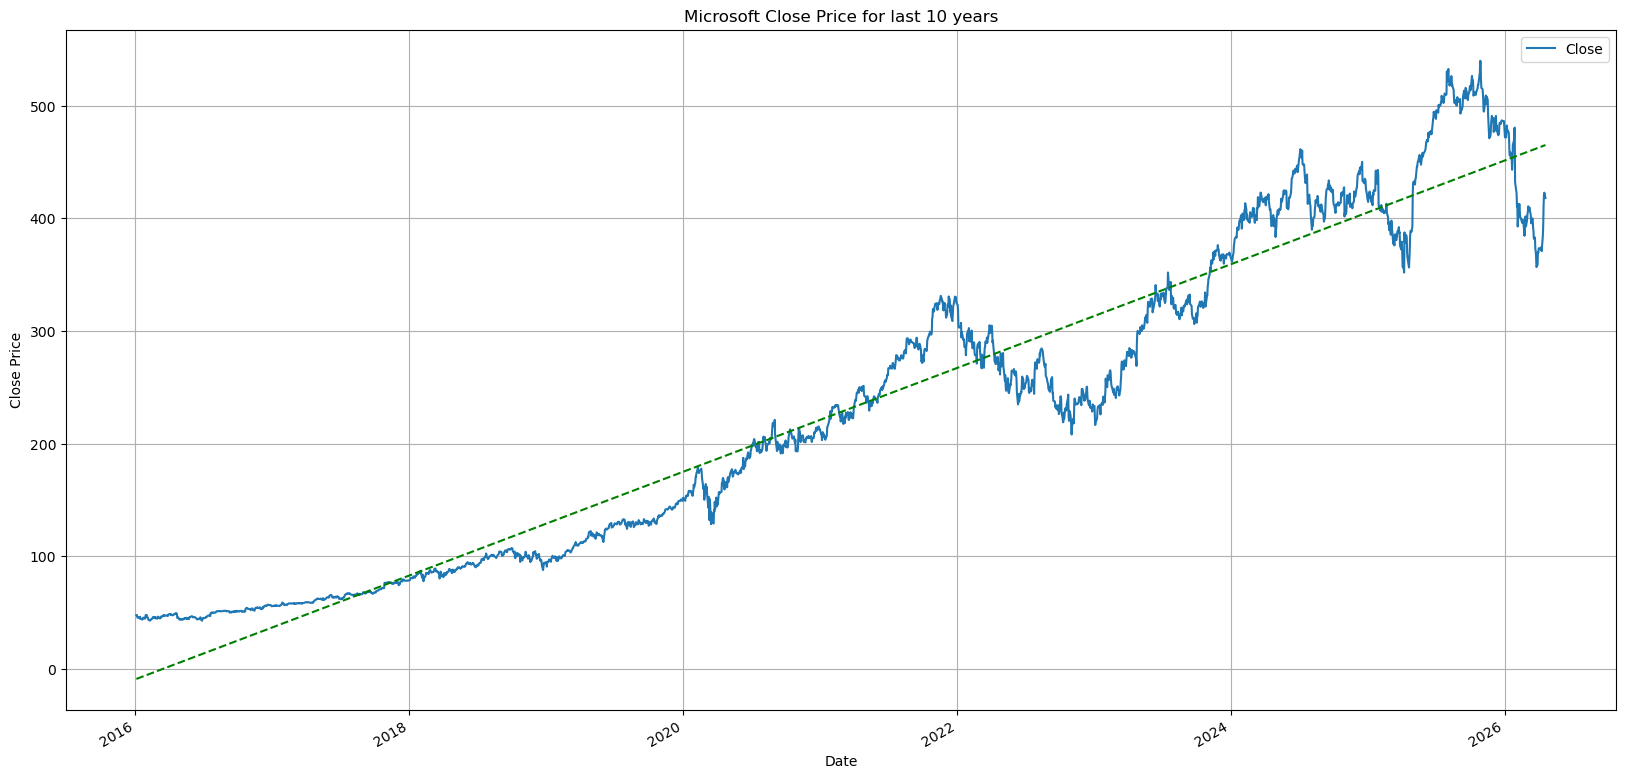

In [74]:
#code for visualization
df.plot(grid=True, figsize=(20,10))
plt.title("Microsoft Close Price for last 10 years")
plt.xlabel("Date")
plt.ylabel("Close Price")

x = mdates.date2num(df.index)
y = df["Close"]
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), "g--")

plt.legend()
plt.show()

   - The graph above shows an upward trend which may indicate a lack of stationarity.  To check for this, we will use an Augmented Dickey-Fuller test to fully evaluate for stationarity as part of the analysis portion of the project.




## Analysis
    
This study will utilize an ARIMA model to forecast future stock prices by analyzing the historical time series data and identifying patterns or trends within the time series.  An ARIMA model is a type of regression analysis that measures one dependent variable’s strength against other changing variables. The model aims to forecast financial market movements by analyzing value differences within the series, not the actual values.  By examining the differences between past and future values, ARIMA assists in predicting trends in financial markets, such as stock prices or company earnings, based on historical performances. An advantage is this model leverages autoregressive properties, making it effective for short-term forecasting where past data significantly influences future outcomes (Hayes, 2026).  

Before the ARIMA model can be built, the data frame must be checked for stationarity using an Augmented Dickey-Fuller test.  If the data is non-stationary, it will be diff’d.  Next, the data will be split into train and test sets.  The time series will then be analyzed for seasonality, trends, autocorrelation, spectral density, decomposed time series and confirmation of the lack of trends in the residuals.  The time series will then be transformed to attain stationarity and remove trends.  Another ADF test will be performed to confirm stationarity.  Once that is complete, an ARIMA model will be identified using auto arima.  A manual ARIMA will also be performed with other orders to verify the p,d,q.  Visualization for Q-Q, Standardized residual, correlogram and histogram will also be generated.  Forecasting will be done from the ARIMA model and MAPE will also be calculated to either reject or accept the null hypothesis.
    
### Limitations and Disadvantages

A disadvantage to an ARIMA model is that it is not built for long-term forecasting (Hayes, 2026).  For this project, the forecast range will be 6 months, so this should not be an issue.  Another possible disadvantage of an ARIMA model is the data must be stationary.  To check for stationarity, an ADF test will be performed and the data will be diff'd if needed.  Low power can be considered a disadvatage of an ADF test as it may not detect stationarity in small samples.  To help prevent this, 10 years of historical data will be uses which is 2588 data points.    

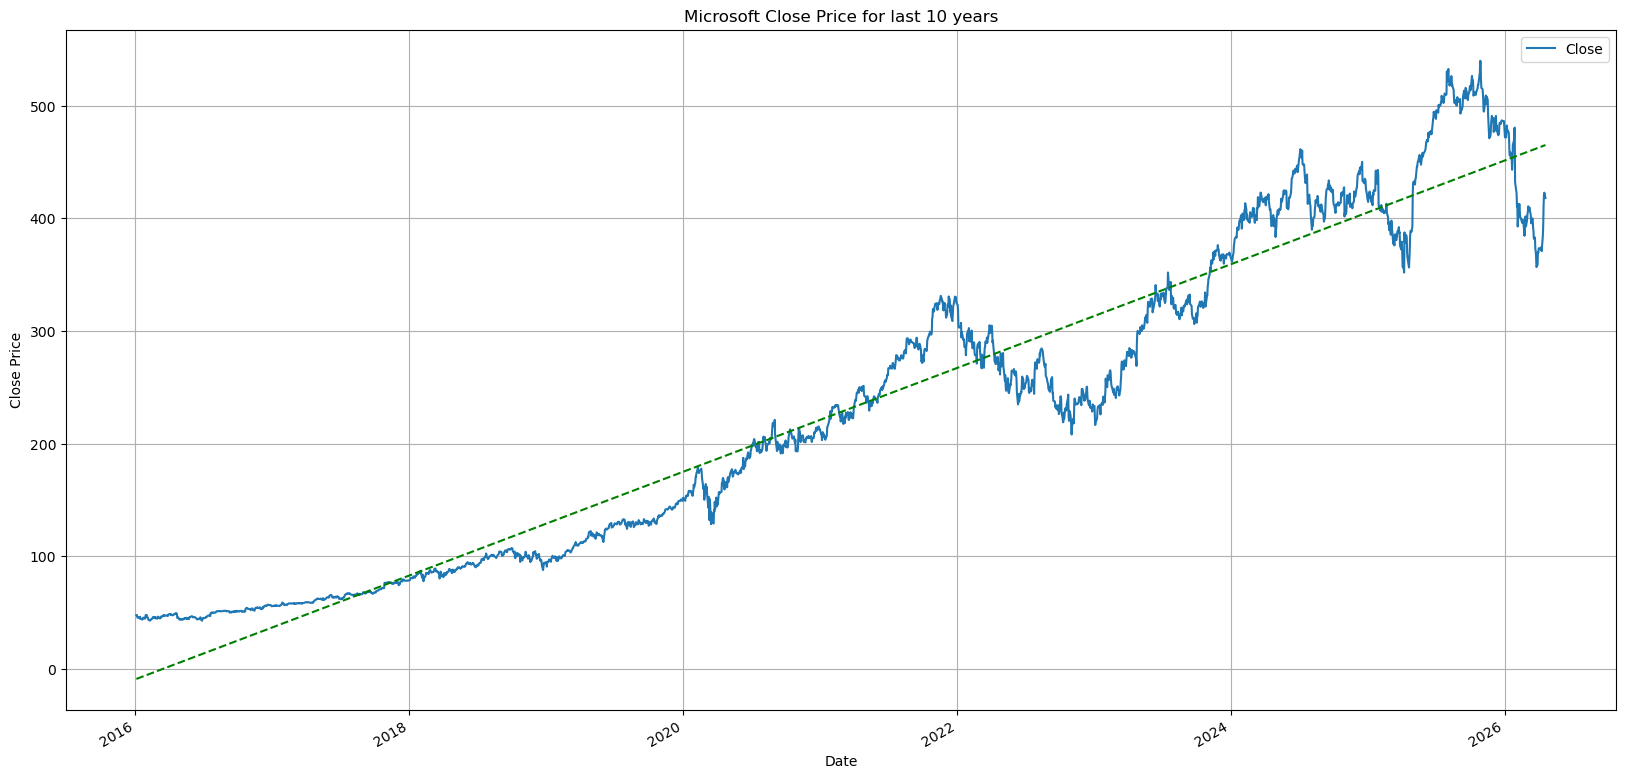

In [75]:
#code for visualization again
df.plot(grid=True, figsize=(20,10))
plt.title("Microsoft Close Price for last 10 years")
plt.xlabel("Date")
plt.ylabel("Close Price")

x = mdates.date2num(df.index)
y = df["Close"]
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(x, p(x), "g--")

plt.legend()
plt.show()

As stated previously, the graph above shows an upward trend which may indicate a lack of stationarity.  To check for this, we will use an Augmented Dickey-Fuller test to fully evaluate for stationarity.

In [76]:
#ADF test
test_adf = adfuller(df)
def check_stationarity(df):
    result = adfuller(df)
    print('ADF Statistic: ', test_adf[0])
    print('P-value: ', test_adf[1])
    print('Critical Values: ', test_adf[4])

check_stationarity(df['Close'])


ADF Statistic:  -0.6655393420584818
P-value:  0.8554748787720912
Critical Values:  {'1%': np.float64(-3.432889109077145), '5%': np.float64(-2.862661779822738), '10%': np.float64(-2.5673671643151064)}


After performing the ADF test, the data was not stationary.  The Close column was passed thru the function and returned a P-value of .86, which is greater than the .05 value.  Since the data is not stationary, we will need to diff the data to make it stationary.  Below is the code used to diff the data as well as an additional ADF test on the diff'd data.


In [77]:
#code for diff'd data and additional ADF
stationary_df = df.diff().dropna()

result = adfuller(stationary_df["Close"])
print("Diff'd ADF Statistics: ", result[0])
print(f"P-Value:  {result[1]:.5f}")
print("Critical Values: ", result[4])

Diff'd ADF Statistics:  -16.775679266673862
P-Value:  0.00000
Critical Values:  {'1%': np.float64(-3.432889109077145), '5%': np.float64(-2.862661779822738), '10%': np.float64(-2.5673671643151064)}


After differencing the data, the time series data is now stationary and ready for forecasting.

In [78]:
#set up Stationairty test
def test_stationarity(timeseries):
    #Determing rolling statistics
    rolmean = timeseries.rolling(window=30).mean()
    rolstd = timeseries.rolling(window=30).std()

    #Plot rolling statistics:
    orig = plt.plot(timeseries, color='blue',label='Original')
    mean = plt.plot(rolmean, color='red', label='Rolling Mean')
    std = plt.plot(rolstd, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)

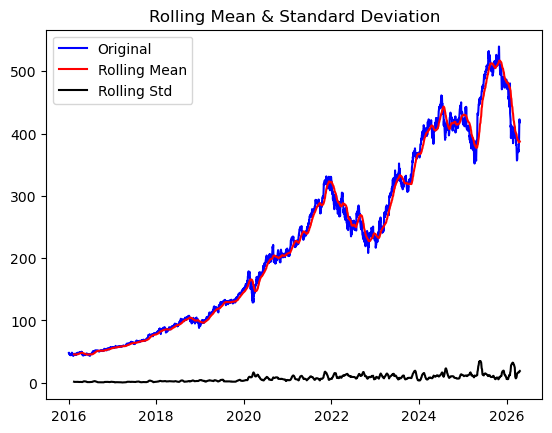

In [79]:
test_stationarity(df['Close'])

In [80]:
#test, train split
# 80/20 split 
train_size = int(len(df) * 0.7)
train, test = df.iloc[:train_size], df.iloc[train_size-1:]



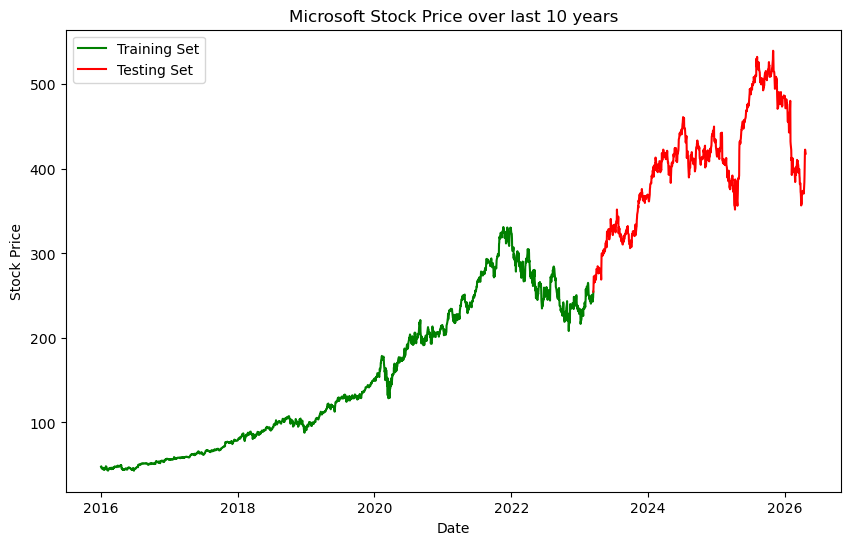

In [81]:
#visual of split
plt.figure(figsize=(10,6))
plt.plot(train['Close'], label = 'Training Set', color='green')
plt.plot(test['Close'], label= 'Testing Set', color='red')
plt.title('Microsoft Stock Price over last 10 years')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [82]:

#export
train.to_csv("train.csv")
test.to_csv("test.csv")

In [83]:
#diff'd to csv(not sure if needed or not )
stationary_df.to_csv("MS_close_diffd.csv")


Steps to prepare the data, including training and test split from code above are as follows:
- Performed ADF test
- Diff'd data for stationarity and reperformed ADF test
- Split data into test and train sets with 70/30 split


Copies of cleaned data(before diff'd), test and train will be attached to submission in csv format.



Next step, the following will be done:

- the presence or lack of a seasonal component

- trends

- the autocorrelation function

- the spectral density

- the decomposed time series

- confirmation of the lack of trends in the residuals of the decomposed series


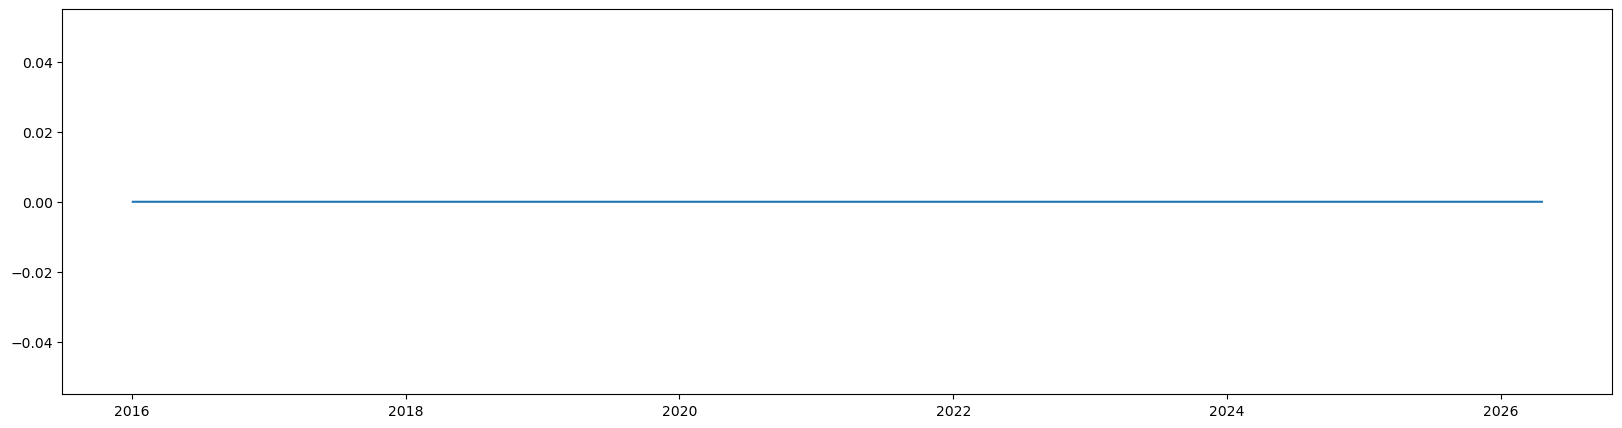

In [84]:
# seasonality

decomposition = seasonal_decompose(df['Close'], model='additive', period=1)
plt.figure(figsize=[20,5])
plt.plot(decomposition.seasonal)
#decomposition.plot()
plt.show()


### Seasonality
- The seasonal plot above shows no seasonal component to the data.  


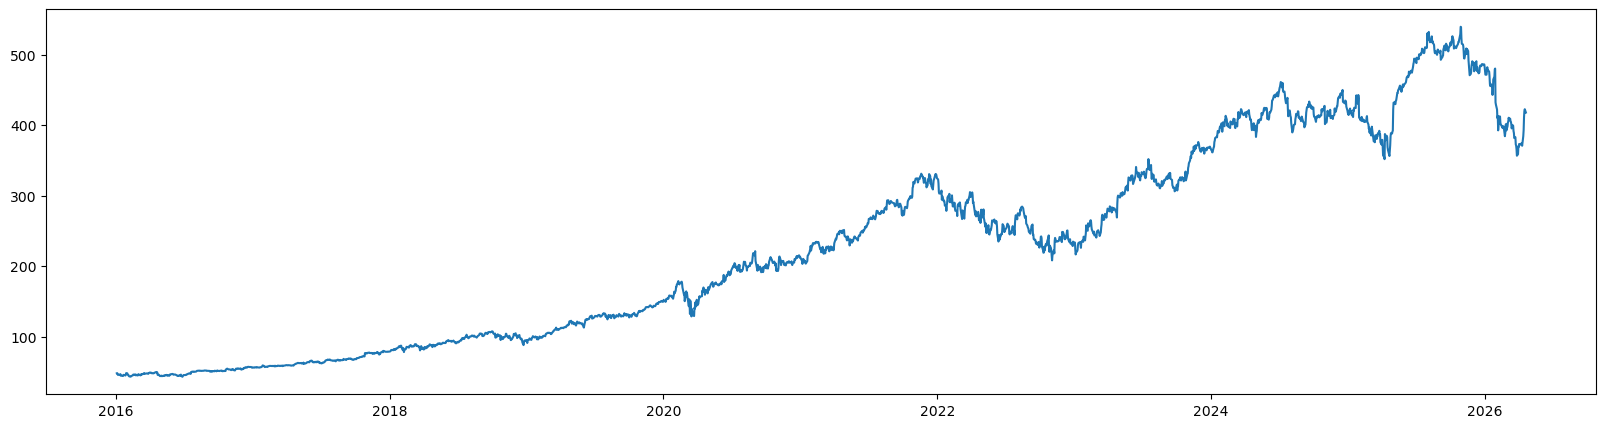

In [85]:
#trend
plt.figure(figsize=[20,5])
plt.plot(decomposition.trend)


### Trends
- The trend plot above shows an upward trend in the data.  It starts on 2016-01 and trends upward to 2026-04.


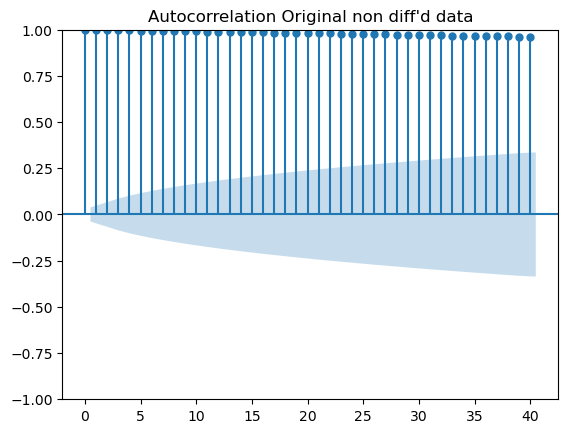

In [86]:
#d1 autocorrelation

#autocorrelation original non diff'd data
plot_acf(df, lags=40)
plt.title("Autocorrelation Original non diff'd data")
plt.show()


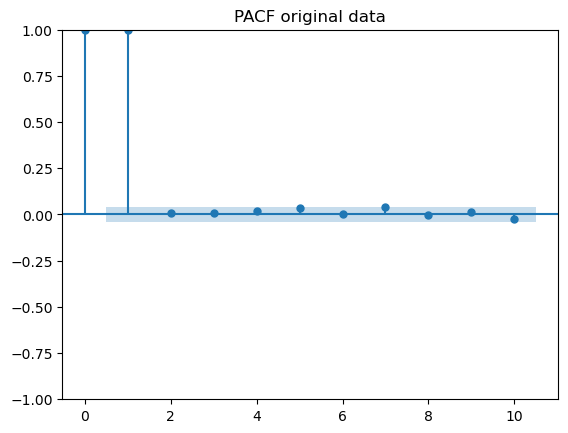

In [87]:

#pacf original data
plot_pacf(df, lags=10)
plt.title("PACF original data")
plt.show()


### Autocorrelation
- The autocorrelation of the original data shows it is not stationary.  You can see the trend line in the plot and that the coefficients do not return to zero, which is expected for that data since it is not stationary.  By looking at both the ACF and PACF above, we can take an educated guess at what the order of our model may be.  With the ACF indicating non stationary data, and the PACF cutting off at lag 1, an ARIMA model of (1,1,0) may be a good fit fit the data.  Auto ARIMA will be used a little later in the project to confirm the assumption.     



(array([6.25658910e+06, 3.28388288e+06, 4.17499944e+03, 2.79245339e+03,
        1.33462835e+03, 1.10184197e+03, 5.66701663e+02, 3.17553918e+02,
        2.21804891e+02, 3.35938568e+02, 1.92465151e+02, 1.72035552e+02,
        1.78042743e+02, 1.45507320e+02, 8.22067308e+01, 8.51247196e+01,
        8.86222307e+01, 9.83962398e+01, 8.28537702e+01, 7.24644108e+01,
        4.20920270e+01, 5.10841553e+01, 1.13817323e+01, 2.53395213e+01,
        4.19366937e+01, 5.99452196e+01, 5.61954937e+01, 3.24849285e+01,
        4.49143698e+01, 4.34051136e+01, 1.33097787e+01, 1.28711872e+01,
        1.22944627e+01, 1.24830616e+01, 2.23113116e+01, 1.80571000e+01,
        8.78248004e+00, 2.10918509e+01, 2.40206071e+01, 8.86444886e+00,
        1.21613128e+01, 5.27230217e+00, 9.92062226e+00, 1.70208209e+01,
        1.82372643e+01, 9.84120243e+00, 1.30921483e+01, 1.80104667e+01,
        1.54967324e+01, 7.05455827e+00, 1.22409935e+01, 1.41600380e+01,
        1.42665156e+01, 1.11947773e+01, 1.06171059e+01, 1.146762

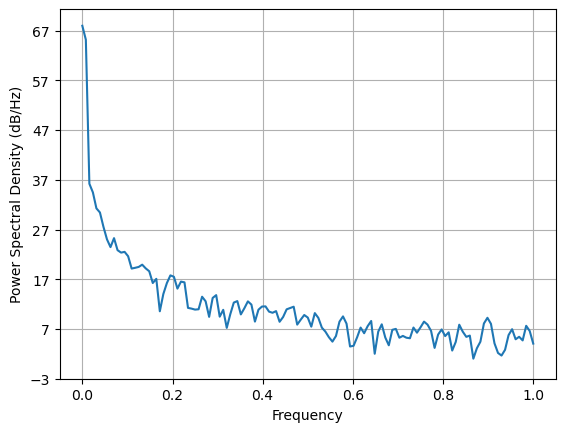

In [88]:
#d1 spectral density

plt.psd(df['Close'])

### Spectral Density
- The power spectral density plot above shows the time and variance between the previous and current time periods or covariance.  It shows a decent amount of overall variability.   

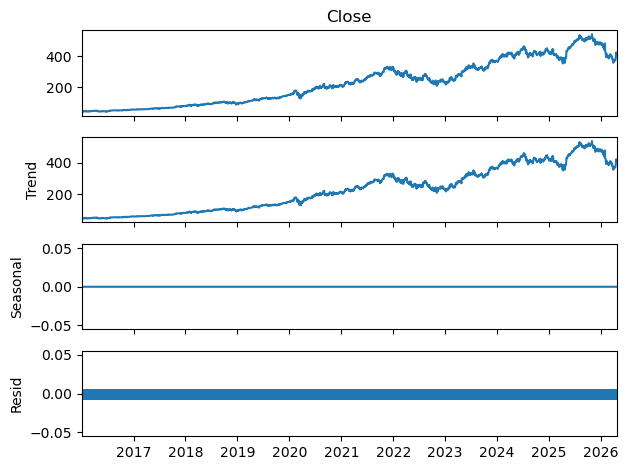

In [89]:
decomposition.plot()
plt.show()

### Decomposed time series
- The above plot is a full decomposed time series.  It shows an upward trend within that data.  It also shows the lack seasonality of the data.  The residuals show they have a constant mean centered at zero.   


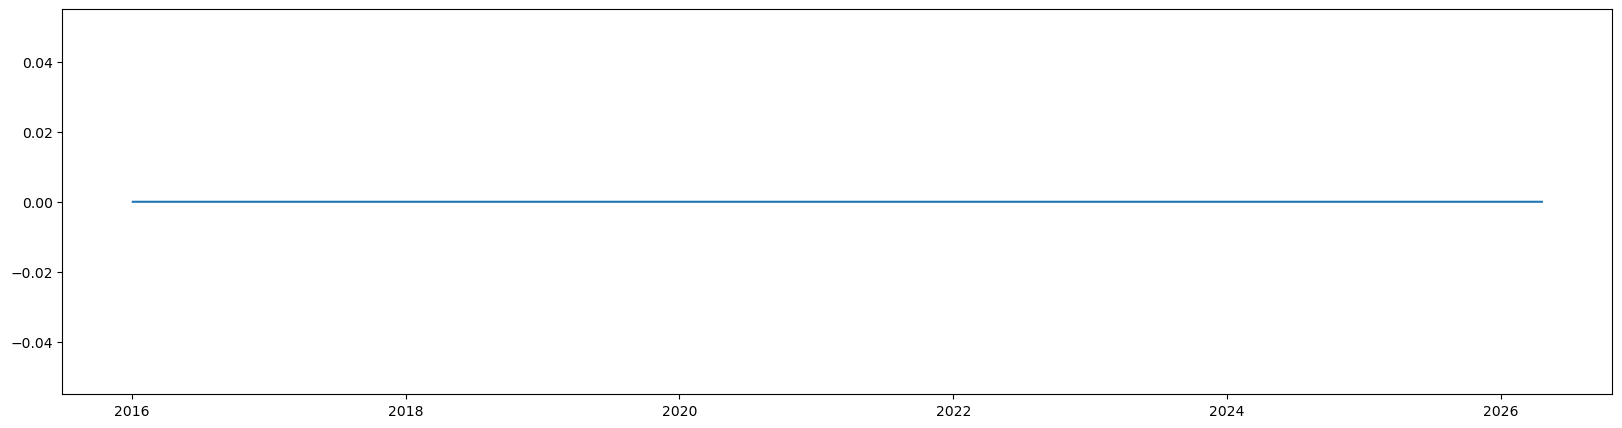

In [90]:
# residuals
plt.figure(figsize=[20,5])
plt.plot(decomposition.resid)

### Trasformation of original data by differencing to attain stationarity and remove trend.

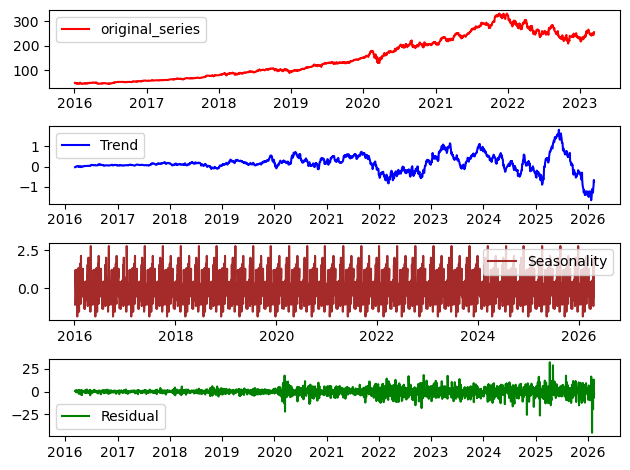

In [91]:
#decompose and plot again after differencing
decomposition=seasonal_decompose(stationary_df, model='additive', period=90)
trend=decomposition.trend
seasonal=decomposition.seasonal
residual=decomposition.resid
plt.subplot(411)
plt.plot(train['Close'],color='red', label='original_series')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(trend,color='blue', label='Trend')
plt.legend(loc='best')
plt.tight_layout()
plt.subplot(414)
plt.plot(residual,color='green', label='Residual')
plt.legend(loc='best')
plt.tight_layout()
plt.subplot(413)
plt.plot(seasonal,color='brown', label='Seasonality')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

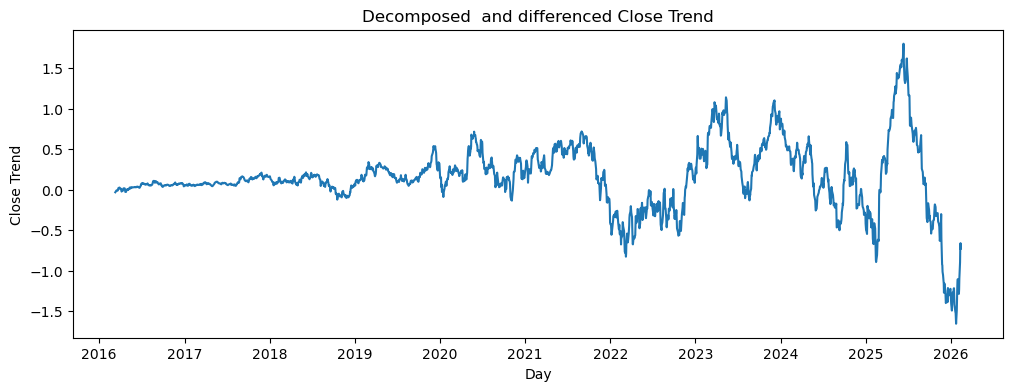

In [92]:
# Plot the trend component only again to confirm trend is eliminated
plt.figure(figsize=(12, 4))
plt.plot(trend, color='tab:blue')
plt.xlabel('Day')
plt.ylabel('Close Trend')
plt.title('Decomposed  and differenced Close Trend')
plt.show()

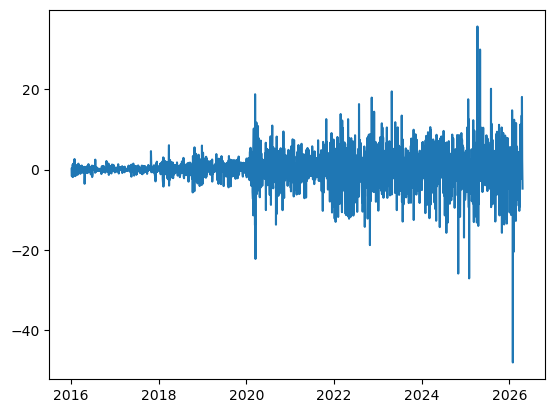

In [93]:
#re-plot of residuals
plt.plot(stationary_df)
plt.show()

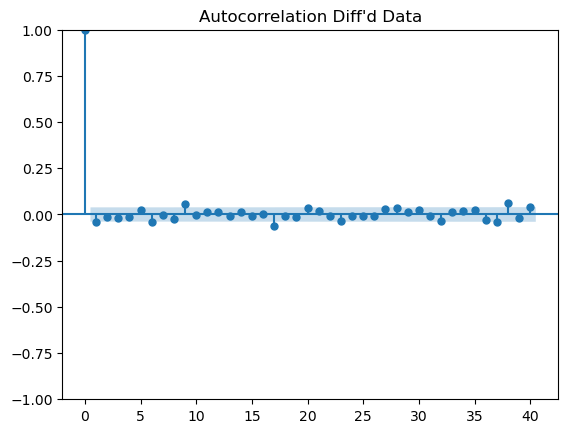

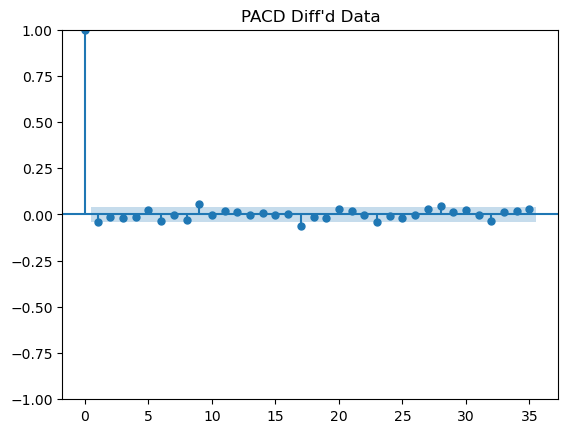

In [94]:
# acf and pacf for diff'd data
plot_acf(stationary_df, lags=40)
plt.title("Autocorrelation Diff'd Data")
plt.show()

plot_pacf(stationary_df)
plt.title("PACD Diff'd Data")
plt.show()


- From the plots above, we can see that the data is now stationary after differencing.  The coefficients quickly center around zero.  

In [95]:
#ADF for differenced data 
adft_diff = adfuller(stationary_df, autolag='AIC')
print("1. ADF c-value : ",adft_diff[0])
print(f"2. P-Value :  {adft_diff[1]:.5f}")
print("3. Num Of Lags : ", adft_diff[2])
print("4. Num Of Observations Used :", adft_diff[3])
print("5. Critical Values :")
for key, val in adft_diff[4].items():
    print("\t",key, ": ", val)

1. ADF c-value :  -16.775679266673862
2. P-Value :  0.00000
3. Num Of Lags :  8
4. Num Of Observations Used : 2578
5. Critical Values :
	 1% :  -3.432889109077145
	 5% :  -2.862661779822738
	 10% :  -2.5673671643151064


- ADF test shows Pvalue is zero which also confirms data is stationary.

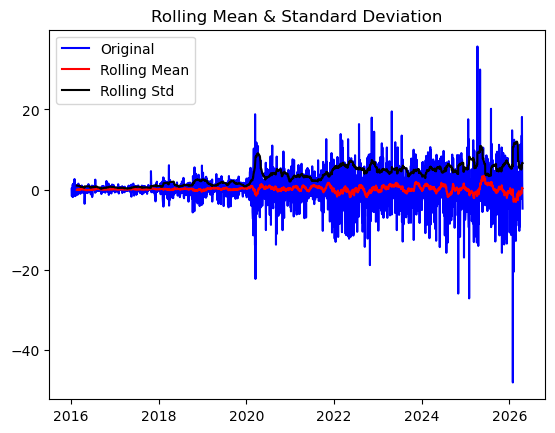

In [96]:
#visualization of confirming stationary data
df_diff=pd.DataFrame(stationary_df)
test_stationarity(df_diff)

- Mean is constant and pretty much at zero.

### Identifing an autoregressive integrated moving average (ARIMA) model that accounts for the observed trend and seasonality of the time series data.

An ARIMA model is a type of regression analysis that measures one dependent variable’s strength against other changing variables. The model aims to forecast financial market movements by analyzing value differences within the series, not the actual values (Hayes, 2026).  This project will utilze the auto_arima function to automatically find the best parameters for our ARIMA model.  The auto_arima function automates the process of fitting different models and deciding which one is best.  In Time Series Analysis, a correct model should yield the highest Log-Likelihood and requires the lowest AIC.  The AIC and BIC of a model depend on the log-likelihood, to be more precise AIC and BIC uses Log-Likelihood in their formula. This would indirectly imply that the log-likelihood is high therefore this method cycles through the model with varying orders and specifications and out of those returns the one with the lowest (Prasad, 2021).  We will also run a couple manual ARIMA's to verify the order of p,d,q from the auto_arima.

AR(p) stands for the autoregressive model, the p parameter is an integer that confirms how many lagged series are going to be used to forecast periods ahead.  I(d) is the differencing part, the d parameter tells how many differencing orders are going to be used to make the series stationary.  MA(q) stands for moving average model, the q is the number of lagged forecast error terms in the prediction equation. SARIMA is a seasonal ARIMA and it is used with time series with seasonality (Prasad, 2021).

### Advantages and Disadvantages

The main advantage to the auto_arima function is that it saves time.  Automating the process of fitting different models to find the best parameters saves an incredible amount of time from what it would take to run all of it manually.  One disadvantage to auto_arima is that you never really get to see how well the other models perform since it gives you the best option.  For this reason, we will be running ARIMA manually with a few different parameters as validation of the auto_arima function.
 


In [97]:
stepwise_fit=auto_arima(df['Close'], trace=True, suppress_warnings=True)
stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=14842.445, Time=0.67 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=14840.486, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=14838.307, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=14838.167, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=14841.407, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=14838.458, Time=0.39 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=14839.472, Time=0.29 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=14840.411, Time=0.69 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=14839.351, Time=0.06 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0] intercept
Total fit time: 2.403 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2588
Model:               SARIMAX(0, 1, 1)   Log Likelihood               -7416.084
Date:                Tue, 15 Sep 2026   AIC                          14838.167
Time:                        12:53:41   BIC                          14855.742
Sample:                             0   HQIC                         14844.537
                               - 2588                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1432      0.081      1.767      0.077      -0.016       0.302
ma.L1         -0.0416      0.014     -2.925      0.003      -0.069      -0.014
sigma2        18.0920      0.191     94.854      0.000      17.718      18.466
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             16552.16
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):              26.23   Skew:                            -0.53
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [98]:

print(df.shape)

print(train.shape, test.shape)

(2588, 1)
(1811, 1) (778, 1)


In [99]:
# best model from above (0,1,1)(0,0,0)[0]
# code arima model order from auto arima
warnings.filterwarnings("ignore")
model = ARIMA(df["Close"], order=(0,1,1))
model_fit = model.fit()
model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 2588
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -7417.676
Date:                Tue, 15 Sep 2026   AIC                          14839.351
Time:                        12:53:55   BIC                          14851.068
Sample:                             0   HQIC                         14843.598
                               - 2588                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0402      0.014     -2.826      0.005      -0.068      -0.012
sigma2        18.1142      0.190     95.459      0.000      17.742      18.486
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             16559.48
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):              26.16   Skew:                            -0.53
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [100]:
# arima model with different orders
#(1,1,0) order from what we thought would be a good fit earlier
model2 = ARIMA(df["Close"], order=(1,1,0))
model2_fit = model2.fit()
model2_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 2588
Model:                 ARIMA(1, 1, 0)   Log Likelihood               -7417.736
Date:                Tue, 15 Sep 2026   AIC                          14839.472
Time:                        12:55:34   BIC                          14851.189
Sample:                             0   HQIC                         14843.719
                               - 2588                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0390      0.014     -2.757      0.006      -0.067      -0.011
sigma2        18.1152      0.189     95.728      0.000      17.744      18.486
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):             16590.37
Prob(Q):                              0.93   Prob(JB):                         0.00
Heteroskedasticity (H):              26.14   Skew:                            -0.53
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.36
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [101]:
# arima model with different orders
#(1,1,1) order from auto arima as 2nd best
model3 = ARIMA(df["Close"], order=(1,1,1))
model3_fit = model3.fit()
model3_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 2588
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -7416.987
Date:                Tue, 15 Sep 2026   AIC                          14839.974
Time:                        12:55:36   BIC                          14857.549
Sample:                             0   HQIC                         14846.344
                               - 2588                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5459      0.192      2.837      0.005       0.169       0.923
ma.L1         -0.5843      0.185     -3.162      0.002      -0.947      -0.222
sigma2        18.1044      0.202     89.833      0.000      17.709      18.499
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):             16011.07
Prob(Q):                              0.88   Prob(JB):                         0.00
Heteroskedasticity (H):              26.19   Skew:                            -0.53
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [102]:
# arima model with different orders
#(0,1,2) order from auto arima as 3rd best
model4 = ARIMA(df["Close"], order=(0,1,2))
model4_fit = model4.fit()
model4_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Close   No. Observations:                 2588
Model:                 ARIMA(0, 1, 2)   Log Likelihood               -7417.383
Date:                Tue, 15 Sep 2026   AIC                          14840.766
Time:                        12:55:38   BIC                          14858.341
Sample:                             0   HQIC                         14847.135
                               - 2588                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.0402      0.014     -2.832      0.005      -0.068      -0.012
ma.L2         -0.0152      0.013     -1.175      0.240      -0.041       0.010
sigma2        18.1101      0.199     90.897      0.000      17.720      18.501
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             16295.81
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):              26.21   Skew:                            -0.53
Prob(H) (two-sided):                  0.00   Kurtosis:                        15.25
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

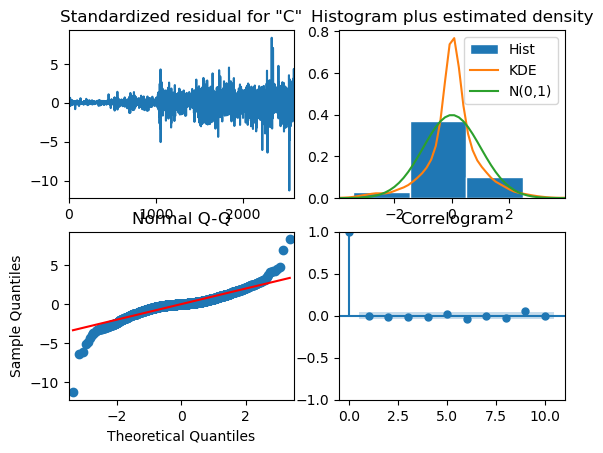

In [103]:
model_fit.plot_diagnostics().show()

- the selection of an ARIMA model

    From the calculations above, the model order of (0,1,1) has the lowest AIC of 14839.351 making it the best.  Our guess of model order(1,1,0) from earlier turned out to be the 2nd best choice of model order with an AIC of 14839.472.  We also tried two other model orders from the auto_arima(1,1,1) & (0,1,2) which came close but still were not better than what the auto_arima function gave us.  

- the prediction interval of the forecast
    
    The observed range is from 2016-01 to 2026-04.  The prediction interval of the forecast has a range of 6 months, 2026-04 to 2026-10.  This will be defined as 180 steps, which also equals 6 months.        

- a justification of the forecast length
    
    The justification of the forecast length was to keep the testing period at a reasonable length since the dataset is very large.  The observed range is 10 years, so setting the forecast to 6 months seemed logical considering the observed range.  A larger forecast could have made the forecast itself lose value and a shorter forecast length may not have provided enough legnth to be valuable.           

- the model evaluation procedure and error metric

    The model evaluation procedure and error metric used are diagnostic_plots() for model performance.  The diagnostic_plots() function generates plots about the model performance.  Above are the plots generated from the function.  The top left is a standardized residual for R plot.  The plot does not show any patterns.  However, there are volatility spikes after index 1000, with a larger negative spike near index 2500 indicating the model is not capturing volatility shifts.  The top right plot is a histogram with KDE.  The KDE curve is more narrow and taller than the N(0,1) curve which indicates an excess of values near zero.  The bottom left plot, is a normal q-q plot.  The values along the red line stray at both ends.  The downward curve on the far left along with the upward curve on the far right confirm the presence of outliers.  The bottom right plot is a correlogram.  This shows the residuals behave like white noise, meaning no significant lag patterns remain.  Any correlations for lag greater than zero are insignificant.

    The error metric was Mean Absolute Percentage Error as seen below.  With a MAPE of .120 or 1.2%, it would indicate our forecasted values are very close to the observed values.  With the MAPE being 1.2%, we can reject the null hypothesis and accept the alternate hypothesis.

We can now run our forecast with the parameters for auto_arima which have been stored in model_fit.  MAPE will also be calculated so we can determine the outcome of our hypothesis.



In [104]:
test_predictions = model_fit.predict(n_periods=len(test))

In [105]:
mape = mean_absolute_percentage_error(df['Close'], test_predictions)
print(f'Mean Absolute Percentage Error: {mape}')

Mean Absolute Percentage Error: 0.01204980145838707


In [ ]:
#mape as percentage
mape_frac = mean_absolute_percentage_error(df['Close'], test_predictions)
mape_per = mape_frac * 100

print(f"MAPE: {mape_per:.2f}%")

MAPE: 1.20%


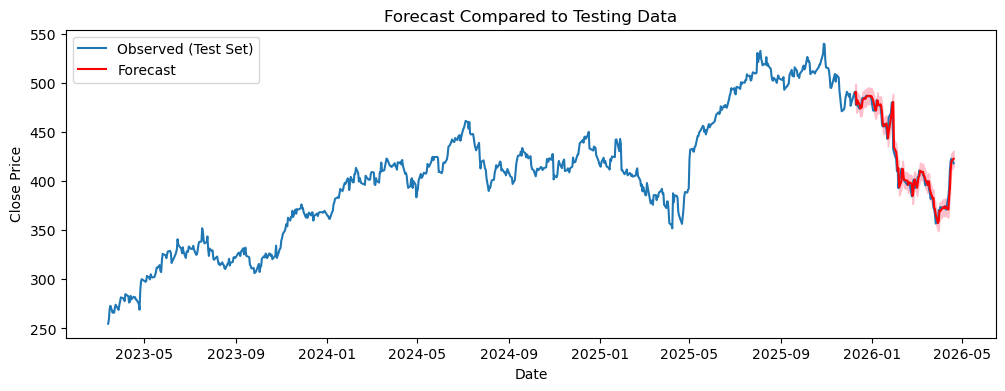

In [107]:
prediction = model_fit.get_prediction(start = -90)
mean_prediction = prediction.predicted_mean
confidence_intervals = prediction.conf_int()
lower_limits = confidence_intervals.loc[:, 'lower Close']
upper_limits = confidence_intervals.loc[:, 'upper Close']

plt.figure(figsize = (12, 4))
plt.plot(test.index, test, label = 'Observed (Test Set)')
plt.plot(mean_prediction.index, mean_prediction, color = 'r', label = 'Forecast')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color = 'pink')
plt.title('Forecast Compared to Testing Data')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

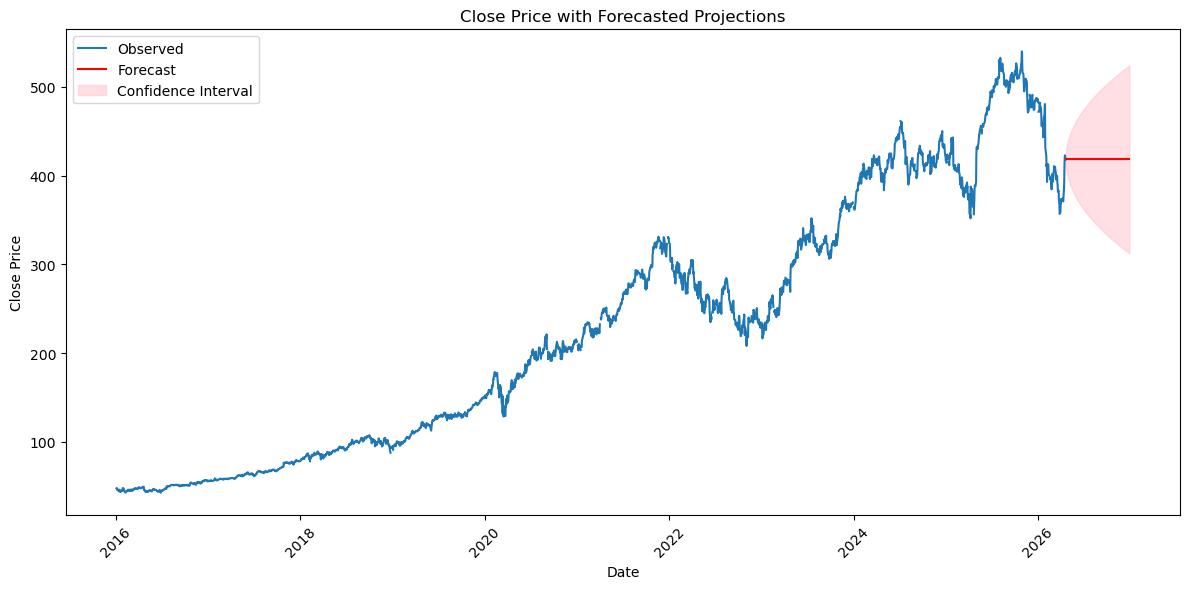

In [108]:
#forecast with observed
df.index = pd.to_datetime(df.index)
df = df.asfreq('B')
model = ARIMA(df['Close'], order=(0, 1, 1)) 
model_fit = model.fit() 
diff_forecast = model_fit.get_forecast(steps=180)
mean_forecast = diff_forecast.predicted_mean
confidence_intervals = diff_forecast.conf_int()


lower_limits = confidence_intervals.iloc[:, 0]
upper_limits = confidence_intervals.iloc[:, 1]


plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'], label='Observed')
plt.plot(mean_forecast.index, mean_forecast, color='r', label='Forecast')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color='pink', alpha=0.5, label='Confidence Interval')

plt.title('Close Price with Forecasted Projections')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

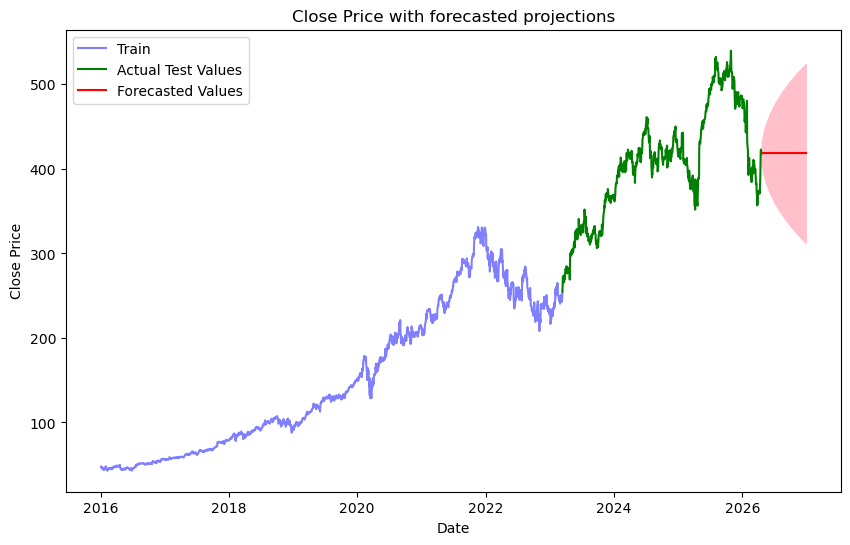

In [109]:
#forecast with train & test in separate colors
plt.figure(figsize=(10,6))
plt.plot(train.index,train, label='Train', color='blue', alpha=0.5)
plt.plot(test.index, test['Close'], label = 'Actual Test Values', color='green')
plt.plot(mean_forecast.index, mean_forecast, label = 'Forecasted Values', color='red')
plt.fill_between(lower_limits.index, lower_limits, upper_limits, color = 'pink')


plt.title('Close Price with forecasted projections')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

## E - Data Summary and Implications

- Summary

    The research question was "Can we forecast the future stock price using time series analysis based on historical stock data?"

    By utilizing an ARIMA model on the historical stock price data of Microsoft, we were able to accuratly forecast future closing prices of Microsoft stock.  The observed range for the model was between 2016-01 & 2026-04, forecasting a range of 6 months in the future.  Investors and share holders can use the information to make informed decisions on future close prices based on historical performance.  

    The results of the error metric, Mean Absolute Percentage Error or MAPE, indicate the model predicts future close prices with 98.8% accuracy.  With an accuracy of 98.8%, we can reject the null hypothesis of our research question and accept the alternate hypothesis of "The future stock price can be predicted with 80% accuracy." 

    One limitation of the analysis of stock price forecasting is that ARIMA only looks at historical data.  Stock prices are often influenced by external factors such as economic shifts, market panic and company reports.  People are unpredictable.  Since people often times influence the stock market, it makes it difficult to forecast furture prices on historical data alone.   

- Course of action

    Based on the findings of this project, it is recommended that the model can be used as a tool by investors and share holders to help make informed decisions on future stock close prices of Microsoft.  With that being said, based on the limitation stated above, the model should not be the only information used by investors and share holders.  It should be combined with other analysis tools to create a more clear picture of the stocks performance.    

- Future Study Recommendations

    1.  Model improvement.  The current models serves as an excellent baseline to build upon.  It is recommended to change some of the parameters of the model such as the observed range and the forecasting range to see if there are any improvements.  Shortening both would be the next step, then compare the results of each.  It would also be beneficial to try different splits in the test and training data.  The current model uses a 70/30 split.

    2.  Explore alternative models.  Due to the limitations of an ARIMA model, it would be beneficial to explore alternative models such as Long Short-Term Memory or LSTM.  LSTMs overcome these limitations by learning long-term relationships and automatically discard useless short-term market noise. They excel at mapping the complex, non-linear trajectories that stock prices actually follow (B, 2025).  Being able to capture the complex patterns of market data would be a valuable asset to both investors and share holders alike.      


### F.  Acknowledge sources, using in-text citations and references, for content that is quoted, paraphrased, or summarized.
   
    B, A. (2025, March 21). Predicting stock prices using lstms: A step-by-step guide to time series forecasting | by aditi B | medium. Medium. https://medium.com/@aditib259/predicting-stock-prices-using-lstms-time-series-forecasting-a-step-by-step-guide-a70ebb04bbb8 

    Bora, N. (2021, November 22). Understanding Arima models for machine learning | by neha bora | capital one tech | medium. Medium. https://medium.com/capital-one-tech/understanding-arima-models-for-machine-learning-capital-one-579a7ae04ba

    Creative commons. Deed - CC0 1.0 Universal - Creative Commons. (n.d.). https://creativecommons.org/publicdomain/zero/1.0/deed.en

    Hayes, A. (2026, July 17). Master Arima: Your guide to time series forecasting. Investopedia. https://www.investopedia.com/terms/a/autoregressive-integrated-moving-average-arima.asp 

    Indicio Technologies. (2024, September 30). Are you held back by outdated historical data in your forecasting? https://www.indicio.com/resources/blog/are-you-held-back-by-outdated-historical-data-in-your-forecasting 

    Lazzeri, F. (2021, November 2). Python open source libraries for scaling time series forecasting solutions | by Francesca Lazzeri | Data Science + AI at Microsoft | Medium. Medium. https://medium.com/data-science-at-microsoft/python-open-source-libraries-for-scaling-time-series-forecasting-solutions-3485c3bd8156

    Loewen, J. (2025, October 24). Three important reasons why I’m tired of Matplotlib | Data Storytelling corner. Medium. https://medium.com/data-storytelling-corner/three-important-reasons-why-im-tired-of-matplotlib-6686683c67a6 

    Minhas, M. S. (2025, January 18). 10 reasons why I stopped using jupyter lab. Towards Data Science. https://towardsdatascience.com/10-reasons-why-i-stopped-using-jupyter-lab-498e958424ac/ 

    Patil, R. (2023, June 19). Exploring the pros and cons of Pandas | by Rohan Patil | Medium. Medium. https://rohanjpatil01.medium.com/exploring-the-pros-and-cons-of-pandas-1675463971d4 

    Prasad, E. (2021, May 20). What is Auto-Arima?. Auto_arima, a routine from imsl… | by Eswara Prasad | featurepreneur | medium. Medium. https://medium.com/featurepreneur/what-is-auto-arima-b8025c6d732d 

    Shamim, A. (2026, April 21). Microsoft Stock Price History. Kaggle. https://www.kaggle.com/datasets/adilshamim8/microsoft-stock-price-history/data
 
    Staff, D. (2022, February 25). What is a jupyter notebook? https://www.databricks.com/blog/what-is-jupyter-notebook 
